# Elaboró:
ROJAS MARTINEZ JONATHAN FRANCISCO

# Vision Computacional — Ejercicios prácticos

Este notebook contiene ejercicios prácticos en Python (OpenCV y scikit-image) sobre **Segmentación**, **Descriptores** y **Morfología matemática**, con explicaciones y preguntas teóricas.

Instrucciones: Ejecuta las celdas en orden. Las imágenes se cargarán desde URLs.

In [1]:
# Celdas iniciales: imports y funciones auxiliares
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray
from skimage import morphology
from urllib.request import urlopen
import io
import math

plt.rcParams['figure.figsize'] = (9,5)

def load_image_url(url, flags=cv2.IMREAD_COLOR):
    """Carga una imagen desde una URL y la devuelve en formato BGR (como cv2 espera) o en escala de grises."""
    resp = urlopen(url)
    data = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    return img

def show_bgr(img, title=''):
    """Muestra imagen BGR usando matplotlib (convierte a RGB)."""
    if img is None:
        print('Imagen vacía')
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img
    plt.imshow(img_rgb, cmap='gray' if img_rgb.ndim==2 else None)
    plt.title(title); plt.axis('off')

def show_gray(img, title=''):
    plt.imshow(img, cmap='gray'); plt.title(title); plt.axis('off')


## 1) Segmentación

En esta sección verás ejemplos de segmentación por umbral, umbral adaptativo y por color (HSV). Las imágenes se cargarán desde URLs de ejemplo; puedes cambiarlas.

### 1.1 Segmentación por umbral (global y adaptativo)

**Objetivo:** separar objetos del fondo usando umbral fijo y adaptativo.


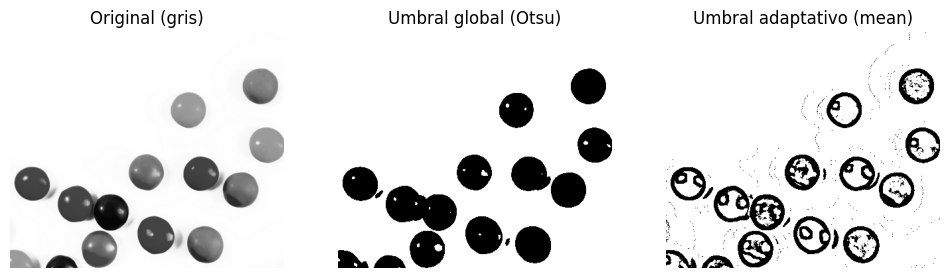

In [2]:
# Ejemplo: umbral simple y adaptativo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png'  # ejemplo público
img = load_image_url(url, flags=cv2.IMREAD_GRAYSCALE)
if img is None:
    print('No se pudo cargar la imagen. Reemplaza la URL por otra válida.')
else:
    # umbral global (Otsu)
    _, th_global = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # umbral adaptativo
    th_adapt = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY, 11, 2)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); show_gray(img, 'Original (gris)')
    plt.subplot(1,3,2); show_gray(th_global, 'Umbral global (Otsu)')
    plt.subplot(1,3,3); show_gray(th_adapt, 'Umbral adaptativo (mean)')
    plt.show()


**Tareas (práctica):**

- Prueba aplicar `cv2.GaussianBlur(img, (5,5), 0)` antes de los umbrales.
- Cambia el tamaño de la ventana en el umbral adaptativo (e.g., 11 → 25) y observa los cambios.


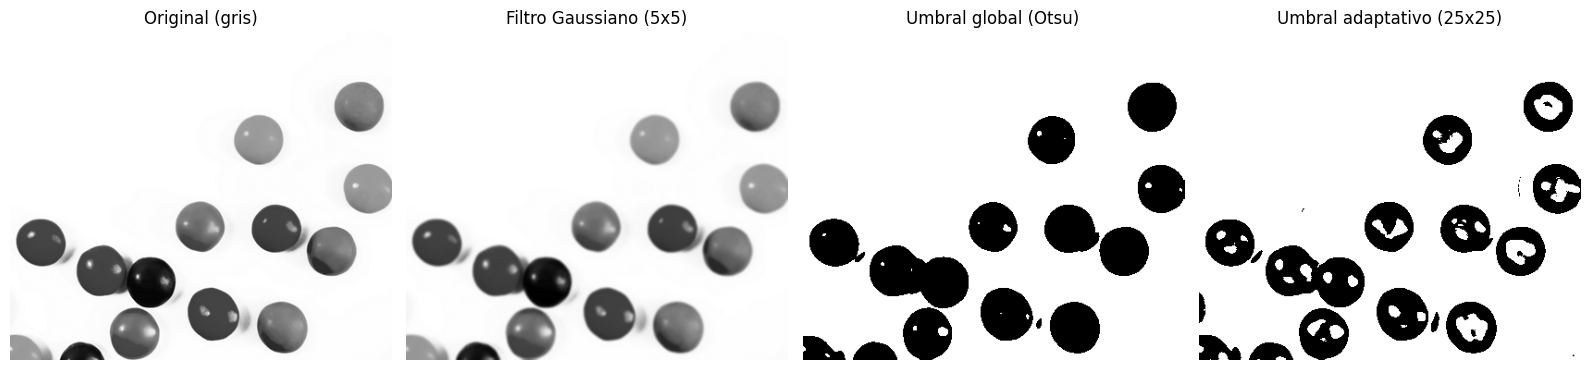

In [3]:
# Aplicar filtro gaussiano
img_blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Umbral global (Otsu) aplicado a la imagen suavizada
_, th_global = cv2.threshold(img_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
# ---------------------------------------------------------
# Umbral adaptativo cambiando la ventana de 11 a 25
# Una ventana más grande evalúa un vecindario mayor para calcular el umbral local.
# ---------------------------------------------------------
th_adapt = cv2.adaptiveThreshold(img_blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25, 2)

    # Visualización de los resultados
plt.figure(figsize=(16, 4)) # Ajustado para acomodar 4 imágenes
    
plt.subplot(1, 4, 1)
show_gray(img, 'Original (gris)')
    
plt.subplot(1, 4, 2)
show_gray(img_blurred, 'Filtro Gaussiano (5x5)')
    
plt.subplot(1, 4, 3)
show_gray(th_global, 'Umbral global (Otsu)')
    
plt.subplot(1, 4, 4)
show_gray(th_adapt, 'Umbral adaptativo (25x25)')
    
plt.tight_layout()
plt.show()

### 1.2 Segmentación por color (espacio HSV)

Detectaremos un color (amarillo) en una imagen ejemplo.


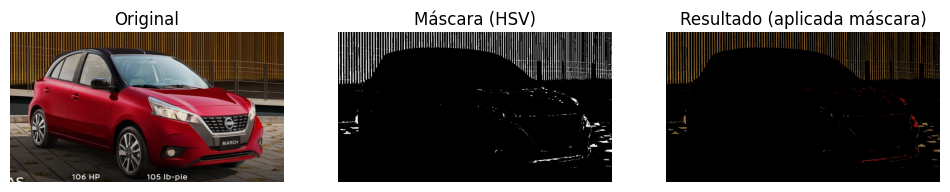

In [4]:
# Ejemplo: segmentación por color (HSV)
link = '../imagenes/carro.png'
img_color = cv2.imread(link, cv2.IMREAD_COLOR)  # carga en color (BGR)
if img_color is None:
    print('No se pudo cargar la imagen. Reemplaza la URL por otra válida.')
else:
    hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
    # rango para amarillo (ajustable) RGB(255,255,0) -> HSV aprox (30,255,255)
    low = np.array([0, 100, 100])
    high = np.array([30, 255, 255])
    mask = cv2.inRange(hsv, low, high)
    res = cv2.bitwise_and(img_color, img_color, mask=mask)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); show_bgr(img_color, 'Original')
    plt.subplot(1,3,2); show_gray(mask, 'Máscara (HSV)')
    plt.subplot(1,3,3); show_bgr(res, 'Resultado (aplicada máscara)')
    plt.show()


**Tareas (práctica):**

- Ajusta los límites `low` y `high` para detectar otros colores (rojo/azul).
- Combina máscaras para detectar objetos multicolor.


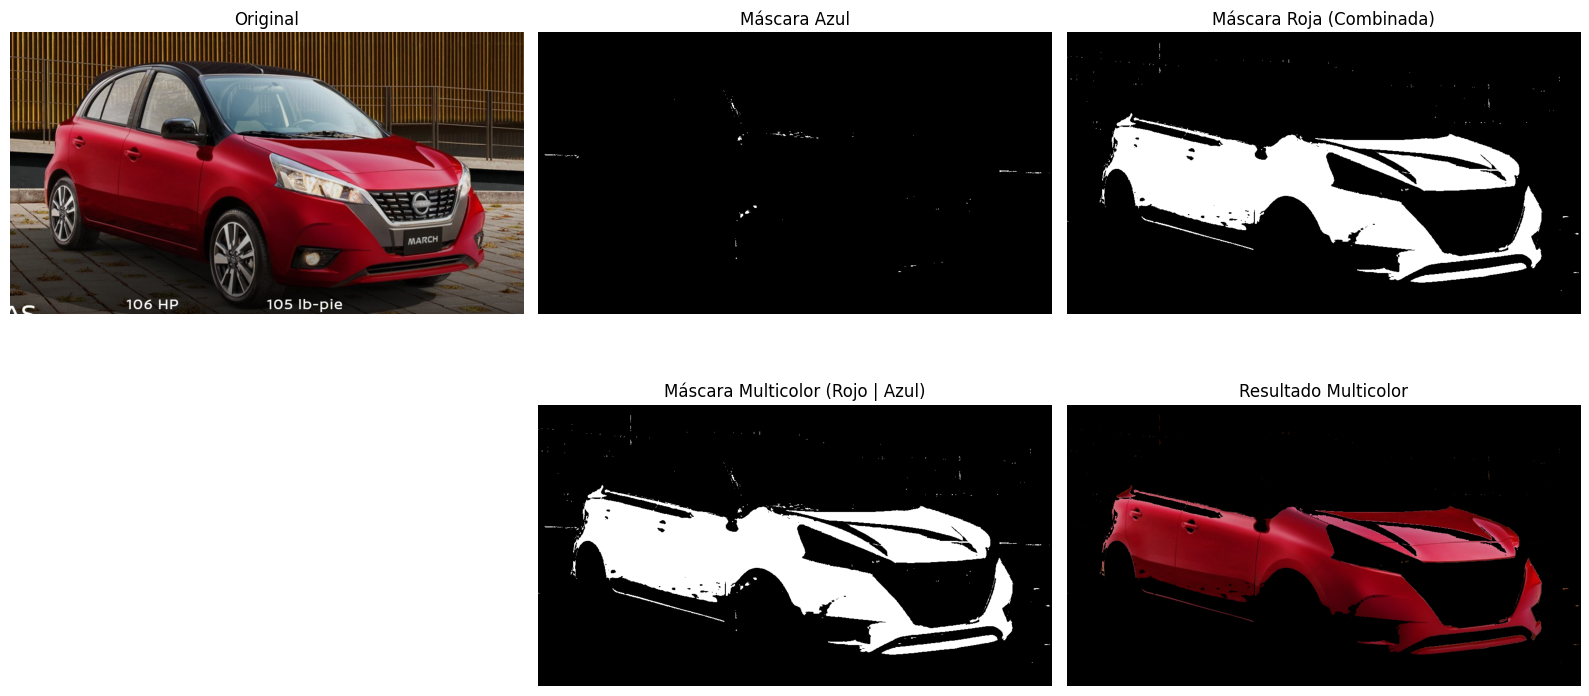

In [5]:
if img_color is None:
    print('No se pudo cargar la imagen.')
else:
    # Convertir a HSV la imagen original
    hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)

    # ---------------------------------------------------------
    # Ajustar límites para Azul y Rojo
    # ---------------------------------------------------------
    
    # Rango para color AZUL
    low_blue = np.array([100, 150, 0])
    high_blue = np.array([140, 255, 255])
    mask_blue = cv2.inRange(hsv, low_blue, high_blue)

    # Rango para color ROJO (Requiere dos máscaras por estar en los bordes del Hue)
    low_red1 = np.array([0, 120, 70])
    high_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv, low_red1, high_red1)

    low_red2 = np.array([170, 120, 70])
    high_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv, low_red2, high_red2)
    
    # Unir las dos partes del rojo
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)

    # ---------------------------------------------------------
    # Combinar máscaras (Objeto multicolor: Rojo + Azul)
    # ---------------------------------------------------------
    
    # Sumar la máscara roja y la máscara azul
    mask_multicolor = cv2.bitwise_or(mask_red, mask_blue)
    
    # Aplicar la máscara combinada a la imagen original
    res_multicolor = cv2.bitwise_and(img_color, img_color, mask=mask_multicolor)


    plt.figure(figsize=(16, 8))
    
    plt.subplot(2, 3, 1)
    show_bgr(img_color, 'Original')
    
    plt.subplot(2, 3, 2)
    show_gray(mask_blue, 'Máscara Azul')
    
    plt.subplot(2, 3, 3)
    show_gray(mask_red, 'Máscara Roja (Combinada)')
    
    plt.subplot(2, 3, 5)
    show_gray(mask_multicolor, 'Máscara Multicolor (Rojo | Azul)')
    
    plt.subplot(2, 3, 6)
    show_bgr(res_multicolor, 'Resultado Multicolor')
    
    plt.tight_layout()
    plt.show()

## 2) Descriptores

Extraeremos propiedades geométricas (momentos de Hu, área, perímetro) y descriptores de textura (LBP).


### 2.1 Momentos de Hu y propiedades de contorno

Calcularemos área, perímetro y los 7 momentos invariantes de Hu para cada contorno.


Contorno 0: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 1: área=0.5, perímetro=3.4, Hu[0]=2.222e-01
Contorno 2: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 3: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 4: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 5: área=0.0, perímetro=2.0, Hu[0]=0.000e+00
Contorno 6: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 7: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 8: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 9: área=0.0, perímetro=4.8, Hu[0]=0.000e+00
Contorno 10: área=0.0, perímetro=2.0, Hu[0]=0.000e+00
Contorno 11: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 12: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 13: área=0.0, perímetro=10.8, Hu[0]=0.000e+00
Contorno 14: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 15: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 16: área=0.0, perímetro=0.0, Hu[0]=0.000e+00
Contorno 17: área=0.0, perímetro=4.0, Hu[0]=0.000e+00
Contorno 18: área=0.0, perímetro=0.0,

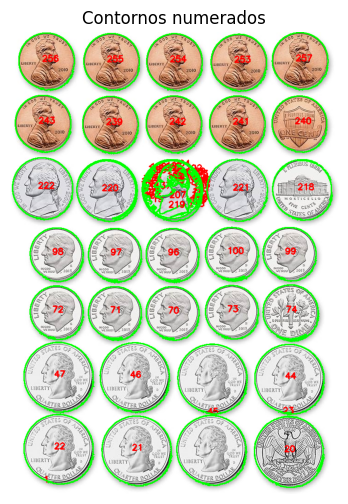

In [6]:
# Ejemplo: momentos de Hu y propiedades de contorno
link = '../imagenes/coin.jpg'  # ejemplo público
img_color = cv2.imread(link, cv2.IMREAD_COLOR)  # carga en color (BGR)
img3_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
_, img3_bin = cv2.threshold(img3_gray, 120, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

contours, _ = cv2.findContours(img3_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

out = img_color.copy()
for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    per = cv2.arcLength(c, True)
    hu = cv2.HuMoments(cv2.moments(c)).flatten()
    # dibujar contorno y centroide
    M = cv2.moments(c)
    if M['m00']!=0:
        cx = int(M['m10']/M['m00']); cy = int(M['m01']/M['m00'])
        cv2.putText(out, f'{i}', (cx-10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    cv2.drawContours(out, [c], -1, (0,255,0), 2)
    print(f'Contorno {i}: área={area:.1f}, perímetro={per:.1f}, Hu[0]={hu[0]:.3e}')

plt.figure(figsize=(10,6)); show_bgr(out, 'Contornos numerados')
plt.show()


**Tareas (práctica):**

- Filtra contornos por área (por ejemplo, `area > 500`).
- Normaliza/transforma los momentos de Hu (log escala) y compara entre objetos.


--- Análisis de Contornos (Área > 500) ---
Objeto 0: Área = 38241.5 | Perímetro = 1068.8
  Hu[0]: Original = 2.361e-01  ->  Log = 0.63
  Hu[1]: Original = 2.463e-02  ->  Log = 1.61
--------------------------------------------------
Objeto 1: Área = 38269.5 | Perímetro = 1088.4
  Hu[0]: Original = 2.441e-01  ->  Log = 0.61
  Hu[1]: Original = 2.741e-02  ->  Log = 1.56
--------------------------------------------------
Objeto 2: Área = 11524.0 | Perímetro = 421.1
  Hu[0]: Original = 1.595e-01  ->  Log = 0.80
  Hu[1]: Original = 9.765e-05  ->  Log = 4.01
--------------------------------------------------
Objeto 3: Área = 11511.0 | Perímetro = 457.2
  Hu[0]: Original = 1.596e-01  ->  Log = 0.80
  Hu[1]: Original = 1.064e-04  ->  Log = 3.97
--------------------------------------------------
Objeto 4: Área = 49722.0 | Perímetro = 1494.4
  Hu[0]: Original = 3.189e-01  ->  Log = 0.50
  Hu[1]: Original = 6.974e-02  ->  Log = 1.16
--------------------------------------------------
Objeto 5: Área

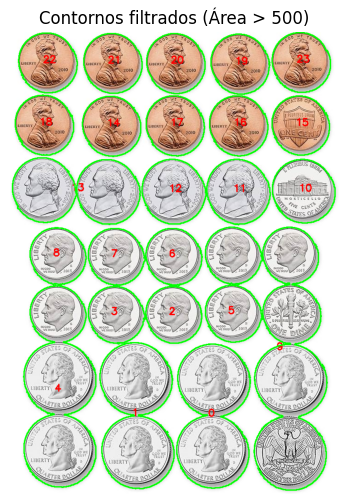

In [7]:
if img_color is None:
    print('No se pudo cargar la imagen.')
else:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    # Usamos THRESH_BINARY_INV porque queremos los objetos blancos sobre fondo negro
    _, img_bin = cv2.threshold(img_gray, 220, 255, cv2.THRESH_BINARY_INV)

    # Encontrar contornos
    contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out = img_color.copy()
    print("--- Análisis de Contornos (Área > 500) ---")
    
    # Contador para identificar los objetos que sí pasan el filtro
    obj_idx = 0 
    
    for c in contours:
        area = cv2.contourArea(c)
        
        # ---------------------------------------------------------
        # Filtrar contornos por área (> 500)
        # ---------------------------------------------------------
        if area > 500:
            per = cv2.arcLength(c, True)
            
            # Calcular momentos básicos
            M = cv2.moments(c)
            # Calcular momentos de Hu
            hu = cv2.HuMoments(M).flatten()
            
            # ---------------------------------------------------------
            # Transformación de Momentos de Hu (escala Log)
            # Fórmula: -1 * signo(h) * log10(abs(h))
            # ---------------------------------------------------------
            hu_log = []
            for h in hu:
                if h == 0:
                    hu_log.append(0)
                else:
                    val = -1 * math.copysign(1.0, h) * math.log10(abs(h))
                    hu_log.append(val)
            
            # Dibujar contorno y centroide
            if M['m00'] != 0:
                cx = int(M['m10']/M['m00'])
                cy = int(M['m01']/M['m00'])
                # Dibujar el número del objeto filtrado
                cv2.putText(out, f'{obj_idx}', (cx-10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            cv2.drawContours(out, [c], -1, (0, 255, 0), 2)
            
            # Imprimir resultados comparativos (solo los primeros 2 momentos de Hu por brevedad)
            print(f'Objeto {obj_idx}: Área = {area:.1f} | Perímetro = {per:.1f}')
            print(f'  Hu[0]: Original = {hu[0]:.3e}  ->  Log = {hu_log[0]:.2f}')
            print(f'  Hu[1]: Original = {hu[1]:.3e}  ->  Log = {hu_log[1]:.2f}')
            print('-' * 50)
            
            obj_idx += 1

    # Visualización final
    plt.figure(figsize=(10, 6))
    show_bgr(out, 'Contornos filtrados (Área > 500)')
    plt.show()

### 2.2 Descriptor de textura: LBP (Local Binary Patterns)

Calcularemos el mapa LBP y su histograma como descriptor.


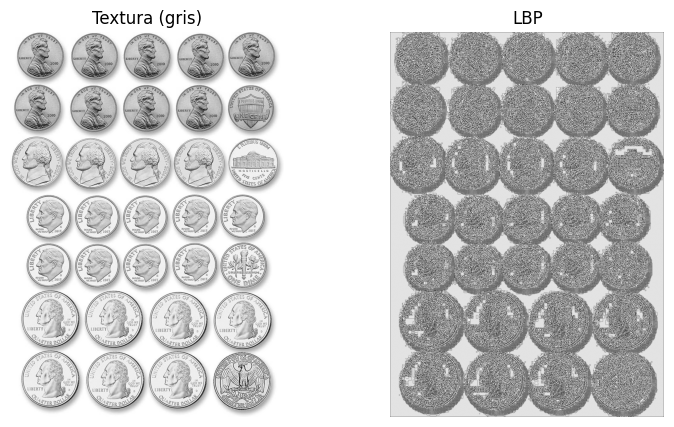

Histograma LBP (primeros 10 valores): [0.07050492 0.07363291 0.02614205 0.06492686 0.14607736 0.09706329
 0.0379128  0.08260619 0.27111111 0.1300225 ]


In [8]:
# Ejemplo: LBP
link = '../imagenes/coin.jpg'  # ejemplo público
img_color = cv2.imread(link, cv2.IMREAD_COLOR)  # carga en color (BGR)
img_gris = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
if img_gris is None:
    print('No se pudo cargar la imagen. Cambia la URL.')
else:
    lbp = local_binary_pattern(img_gris, P=8, R=1, method='uniform')
    # histograma (normalizado)
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    plt.subplot(1,2,1); show_gray(img_gris, 'Textura (gris)')
    plt.subplot(1,2,2); show_gray(lbp, 'LBP')
    plt.show()
    print('Histograma LBP (primeros 10 valores):', hist[:10])


**Tareas (práctica):**

- Usa el histograma LBP como vector descriptor y compara dos imágenes (distancia euclidiana o coseno).
- Experimenta con diferentes `P` y `R` en LBP.


--- Resultados para P=8, R=1 ---
Distancia Euclidiana: 0.1062
Distancia Coseno:     0.0506

--- Resultados para P=16, R=2 ---
Distancia Euclidiana: 0.1265
Distancia Coseno:     0.0291



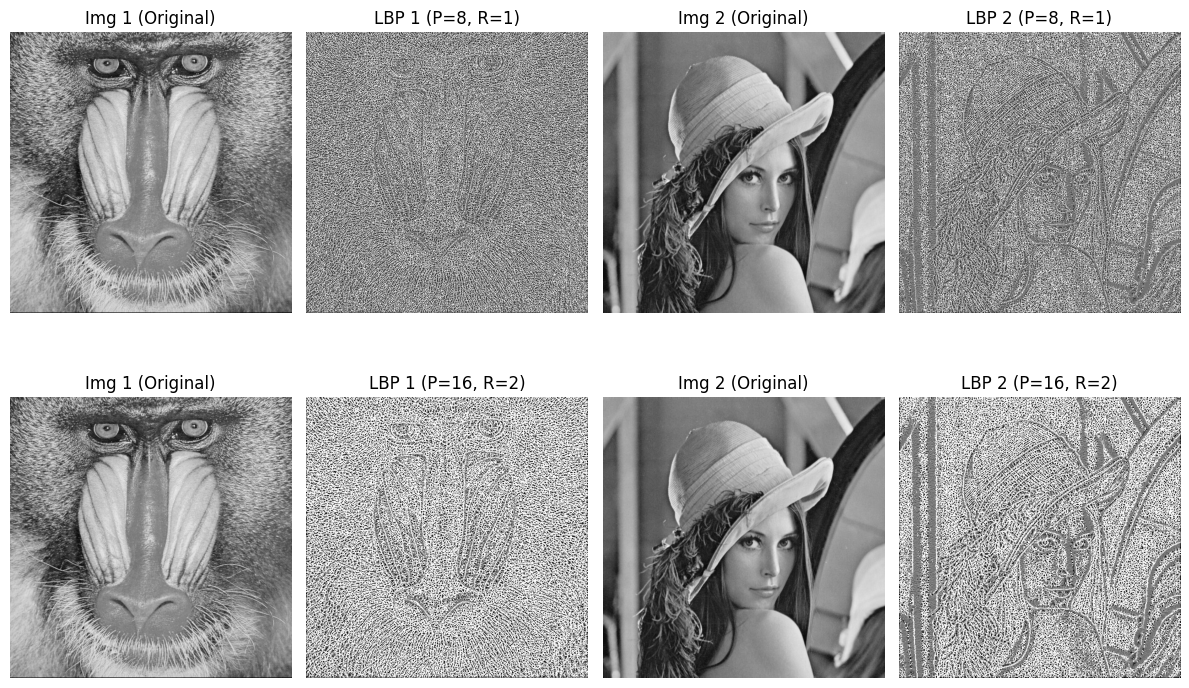

In [9]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

# --- Funciones auxiliares ---
def load_image_url_gray(url):
    try:
        req = urllib.request.urlopen(url)
        arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    except Exception as e:
        print(f"Error cargando la URL: {e}")
        return None

def show_gray(img, title=''):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

def get_lbp_histogram(img, P, R):
    """Calcula el histograma normalizado de LBP para una imagen dadas P y R."""
    lbp = local_binary_pattern(img, P=P, R=R, method='uniform')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return lbp, hist

# Cargar imágenes (Baboon tiene mucha textura, Lena es más suave)
url_img1 = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg'
url_img2 = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'

img1 = load_image_url_gray(url_img1)
img2 = load_image_url_gray(url_img2)

if img1 is None or img2 is None:
    print('No se pudieron cargar las imágenes.')
else:
    # ---------------------------------------------------------
    # Experimentar con diferentes P y R
    # Configuracion 1: P=8, R=1 (Textura fina, escala pequeña)
    # Configuracion 2: P=16, R=2 (Textura gruesa, escala mayor)
    # ---------------------------------------------------------
    configs = [(8, 1), (16, 2)]
    
    plt.figure(figsize=(12, 8))
    
    for i, (P, R) in enumerate(configs):
        # Calcular LBP e histogramas
        lbp1, hist1 = get_lbp_histogram(img1, P, R)
        lbp2, hist2 = get_lbp_histogram(img2, P, R)
        
        # ---------------------------------------------------------
        # Comparar los vectores (Distancia Euclidiana y Coseno)
        # ---------------------------------------------------------
        # Distancia Euclidiana: Norma de la diferencia de los vectores
        dist_euclidiana = np.linalg.norm(hist1 - hist2)
        
        # Distancia Coseno: 1 - (Producto punto / Producto de normas)
        # (Mientras más cerca a 0, más similares son)
        similitud_coseno = np.dot(hist1, hist2) / (np.linalg.norm(hist1) * np.linalg.norm(hist2))
        dist_coseno = 1 - similitud_coseno
        
        print(f"--- Resultados para P={P}, R={R} ---")
        print(f"Distancia Euclidiana: {dist_euclidiana:.4f}")
        print(f"Distancia Coseno:     {dist_coseno:.4f}\n")
        
        # Visualización
        plt.subplot(2, 4, i*4 + 1); show_gray(img1, f'Img 1 (Original)')
        plt.subplot(2, 4, i*4 + 2); show_gray(lbp1, f'LBP 1 (P={P}, R={R})')
        plt.subplot(2, 4, i*4 + 3); show_gray(img2, f'Img 2 (Original)')
        plt.subplot(2, 4, i*4 + 4); show_gray(lbp2, f'LBP 2 (P={P}, R={R})')

    plt.tight_layout()
    plt.show()

## 3) Morfología matemática

Operaciones básicas y una práctica de granulometría.


### 3.1 Erosión, dilatación, apertura y cierre

Aplicaremos operaciones morfológicas sobre una imagen binaria con ruido.


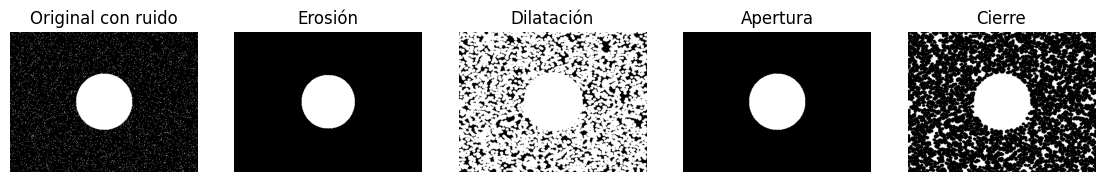

In [10]:
# Ejemplo: operaciones morfológicas
h, w = 300, 400
np.random.seed(0)
img_noise = (np.random.rand(h,w) > 0.96).astype('uint8') * 255
# añadimos un objeto grande
cv2.circle(img_noise, (200,150), 60, 255, -1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
erosion = cv2.erode(img_noise, kernel, iterations=1)
dilat = cv2.dilate(img_noise, kernel, iterations=1)
apertura = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel)
cierre = cv2.morphologyEx(img_noise, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(14,4))
plt.subplot(1,5,1); show_gray(img_noise, 'Original con ruido')
plt.subplot(1,5,2); show_gray(erosion, 'Erosión')
plt.subplot(1,5,3); show_gray(dilat, 'Dilatación')
plt.subplot(1,5,4); show_gray(apertura, 'Apertura')
plt.subplot(1,5,5); show_gray(cierre, 'Cierre')
plt.show()


**Tareas (práctica):**

- Cambia el tamaño y la forma del elemento estructurante (`cv2.getStructuringElement`) y observa efectos.


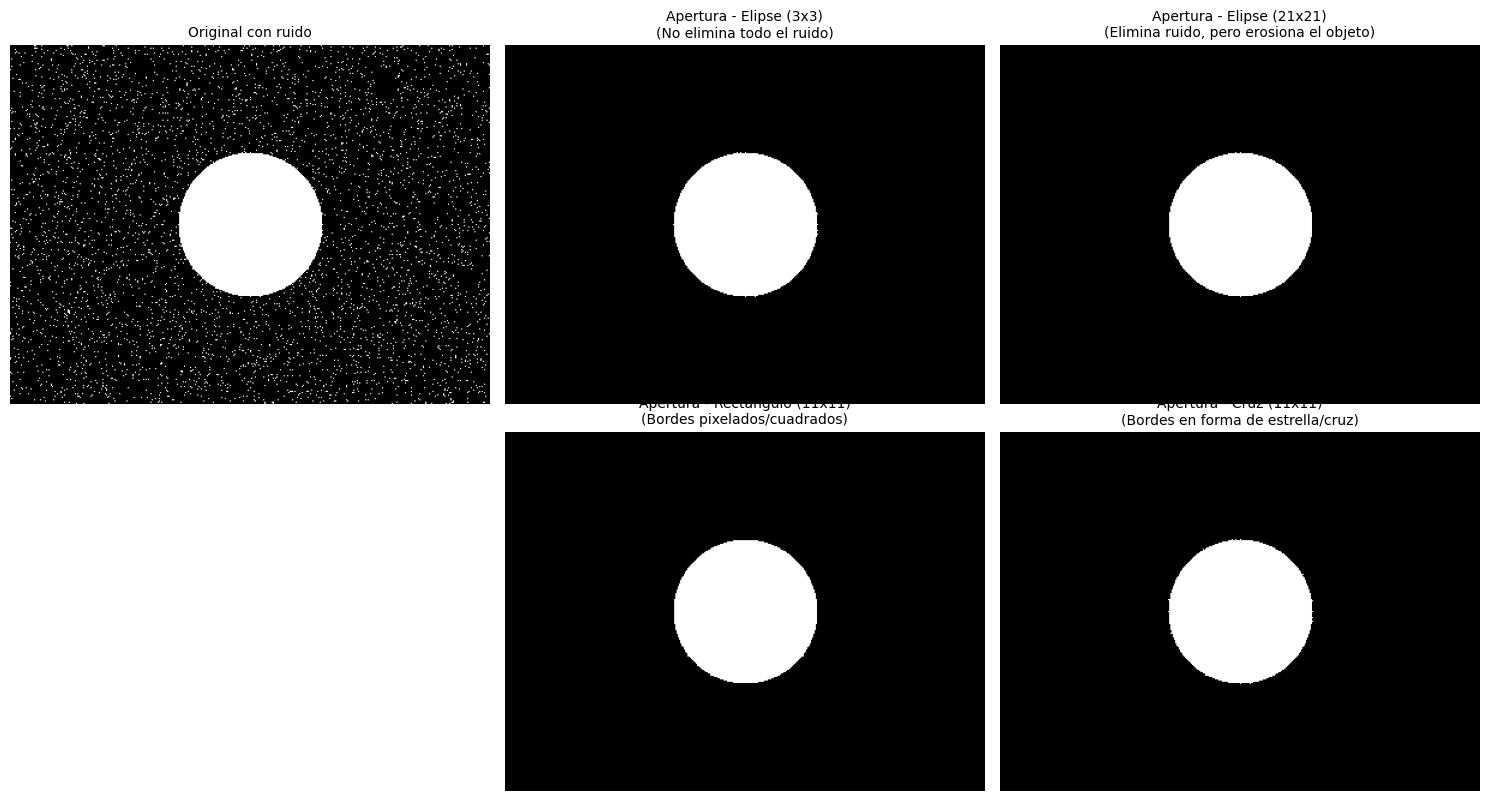

In [11]:
# --- Función auxiliar ---
def show_gray(img, title=''):
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title, fontsize=10)
    plt.axis('off')

# imagen original con ruido y el círculo
h, w = 300, 400
np.random.seed(0)
img_noise = (np.random.rand(h, w) > 0.96).astype('uint8') * 255
cv2.circle(img_noise, (200, 150), 60, 255, -1)

# ---------------------------------------------------------
# Cambiar tamaño y forma del elemento estructurante
# ---------------------------------------------------------

# Comparación de TAMAÑO (Elípticos)
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))

# Comparación de FORMA (Rectángulo vs Cruz) de tamaño medio
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT, (11, 11))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (11, 11))

# Aplicamos la operación de Apertura (Erosión seguida de Dilatación)
apertura_small = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel_small)
apertura_large = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel_large)
apertura_rect  = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel_rect)
apertura_cross = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, kernel_cross)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
show_gray(img_noise, 'Original con ruido')

plt.subplot(2, 3, 2)
show_gray(apertura_small, 'Apertura - Elipse (3x3)\n(No elimina todo el ruido)')

plt.subplot(2, 3, 3)
show_gray(apertura_large, 'Apertura - Elipse (21x21)\n(Elimina ruido, pero erosiona el objeto)')

plt.subplot(2, 3, 5)
show_gray(apertura_rect, 'Apertura - Rectángulo (11x11)\n(Bordes pixelados/cuadrados)')

plt.subplot(2, 3, 6)
show_gray(apertura_cross, 'Apertura - Cruz (11x11)\n(Bordes en forma de estrella/cruz)')

plt.tight_layout()
plt.show()

### 3.2 Granulometría morfológica

Estimaremos el cambio de área blanca restante al aplicar aperturas con elementos crecientes.


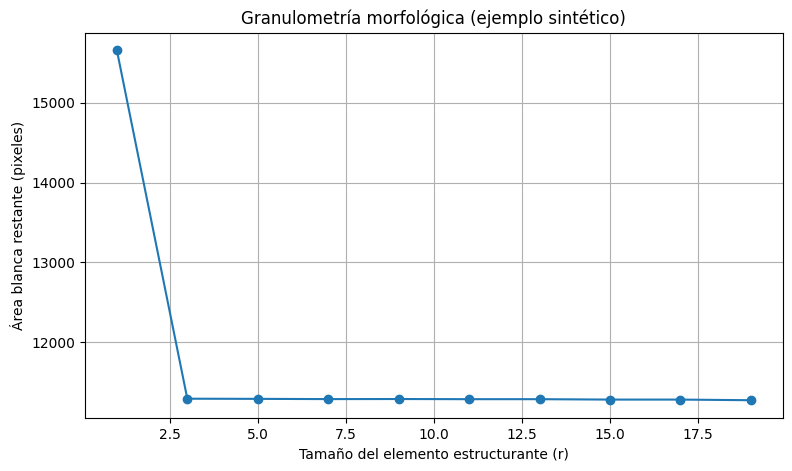

In [12]:
# Ejemplo: granulometría morfológica
areas = []
radii = list(range(1, 20, 2))
for r in radii:
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (r, r))
    opened = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, k)
    area = np.sum(opened == 255)
    areas.append(area)

plt.plot(radii, areas, marker='o')
plt.xlabel('Tamaño del elemento estructurante (r)')
plt.ylabel('Área blanca restante (pixeles)')
plt.title('Granulometría morfológica (ejemplo sintético)')
plt.grid(True)
plt.show()


**Tareas (práctica):**

- Interpreta la gráfica: picos y caídas ¿qué indican sobre la distribución de tamaños de partículas?
- Implementa la versión que calcula la derivada discreta del vector `areas` para estimar la 'densidad de tamaños'.


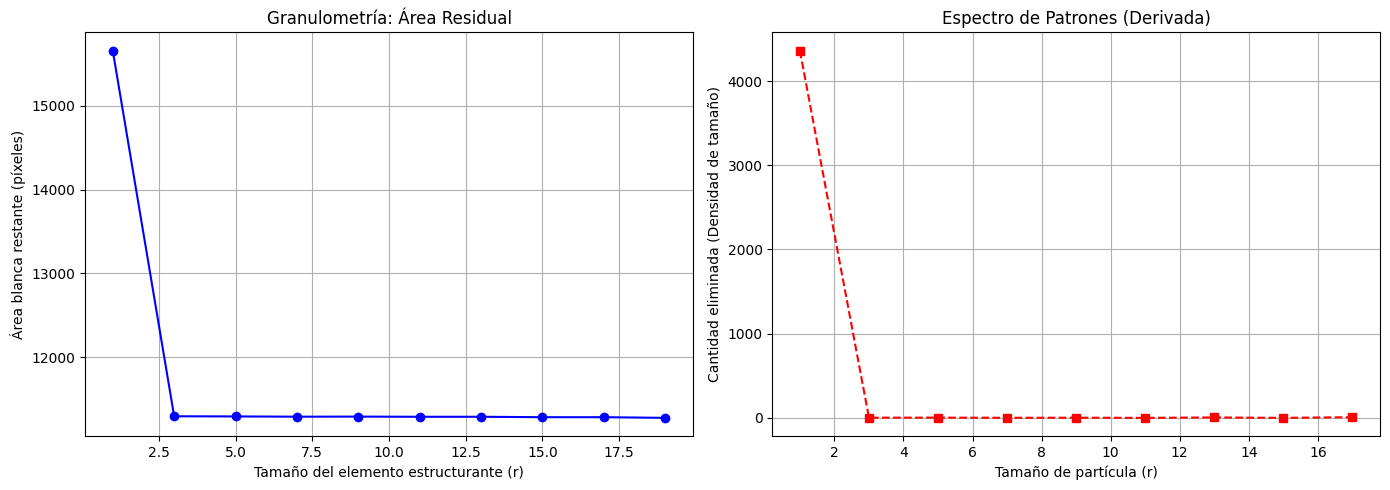

In [13]:
# ---------------------------------------------------------
# Recreamos la imagen base (ruido + un objeto grande)
# ---------------------------------------------------------
h, w = 300, 400
np.random.seed(0)
img_noise = (np.random.rand(h, w) > 0.96).astype('uint8') * 255
cv2.circle(img_noise, (200, 150), 60, 255, -1) # Círculo de radio 60

# ---------------------------------------------------------
# Cálculo de la Granulometría Clásica
# ---------------------------------------------------------
areas = []
radii = list(range(1, 20, 2))

for r in radii:
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (r, r))
    opened = cv2.morphologyEx(img_noise, cv2.MORPH_OPEN, k)
    area = np.sum(opened == 255)
    areas.append(area)

# ---------------------------------------------------------
# Cálculo de la derivada discreta (Espectro de Patrones)
# ---------------------------------------------------------
# np.diff(areas) resta areas[i+1] - areas[i]. Como el área siempre 
# disminuye, el resultado es negativo. asi que usamos np.abs() para evitar errores.
densidad_tamanos = np.abs(np.diff(areas))

# Los radios correspondientes a la derivada son un elemento menos 
# que la lista original de radios (tomamos los tamaños iniciales del salto)
radii_derivada = radii[:-1]


plt.figure(figsize=(14, 5))

# 1. Gráfica original (Área acumulada)
plt.subplot(1, 2, 1)
plt.plot(radii, areas, marker='o', color='blue')
plt.xlabel('Tamaño del elemento estructurante (r)')
plt.ylabel('Área blanca restante (píxeles)')
plt.title('Granulometría: Área Residual')
plt.grid(True)

# 2. Gráfica de densidad (Espectro de patrones)
plt.subplot(1, 2, 2)
plt.plot(radii_derivada, densidad_tamanos, marker='s', color='red', linestyle='--')
plt.xlabel('Tamaño de partícula (r)')
plt.ylabel('Cantidad eliminada (Densidad de tamaño)')
plt.title('Espectro de Patrones (Derivada)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 4) Preguntas teóricas (para evaluar)

Responde brevemente — 4 preguntas por tema.

### Segmentación
1. ¿Cuál es la diferencia entre umbral global y umbral adaptativo? ¿Cuándo usarías cada uno?

El umbral global aplica un único valor límite $T$ a toda la imagen, mientras que el adaptativo calcula un umbral $T(x,y)$ localmente para cada vecindad de píxeles. \textit{Uso:} Global para imágenes con iluminación uniforme; adaptativo para imágenes con sombras, gradientes o iluminación irregular.

2. ¿Qué ventajas aporta segmentar en HSV vs RGB?

El espacio HSV aísla la información del color (Matiz/Hue) de la intensidad luminosa (Valor/Value). Esto hace que la segmentación sea mucho más robusta ante cambios de iluminación y sombras en comparación con RGB, donde los tres canales están fuertemente correlacionados con la luz.

3. Menciona dos limitaciones comunes de la segmentación por color.

    1) Sensibilidad a reflejos especulares o condiciones extremas de luz que alteran el matiz percibido. 
    2) Incapacidad para diferenciar semánticamente objetos distintos que poseen el mismo color (ej. una manzana roja sobre un mantel rojo).

4. ¿Qué es Otsu y para qué sirve?

Es un algoritmo automático que calcula el umbral global óptimo. Sirve para binarizar una imagen maximizando la varianza inter-clase (separación entre la clase "fondo" y la clase "objeto") en el histograma.


### Descriptores
1. ¿Qué propiedades invariantes capturan los momentos de Hu?

Capturan características de la forma geométrica que son invariantes a la traslación, rotación y cambios de escala.

2. ¿Por qué normalizamos histogramas de LBP antes de compararlos?

Se normalizan (dividiendo por la suma total de valores) para que el histograma resultante sea invariante al tamaño (resolución o cantidad de píxeles) de la región o imagen analizada.

3. Da un ejemplo de cuándo usarías un descriptor global vs local.

Usarías un descriptor \textit{global} (ej. Histograma de color) para clasificar el contexto general de una escena (playa vs. bosque). Usarías un \textit{local} (ej. SIFT, ORB) para encontrar un objeto específico o hacer \textit{stitching} (panorámicas), ya que manejan bien las oclusiones parciales.

4. ¿Qué es la relación entre perímetro y área para distinguir formas (ejemplo: círculo vs figura alargada)?

Se define matemáticamente como $C = \frac{4\pi \times \text{Área}}{\text{Perímetro}^2}$. Para un círculo perfecto $C \approx 1$. Para formas alargadas, irregulares o complejas, $C$ tiende a $0$.


### Morfología matemática
1. Describe en una frase la diferencia entre apertura y cierre.

La apertura elimina ruidos pequeños y suaviza contornos externos, mientras que el cierre rellena agujeros pequeños y une estructuras que están muy cerca entre sí.

2. ¿Qué efecto tiene un elemento estructurante grande vs pequeño?

Un elemento pequeño filtra detalles finos sin alterar significativamente el objeto principal; un elemento grande modifica la geometría sustancialmente, pudiendo eliminar o fusionar objetos enteros.

3. ¿Para qué sirve la granulometría morfológica?

Sirve para estimar la distribución de tamaños de las partículas u objetos en una imagen, aplicando aperturas sucesivas con elementos estructurantes de tamaño creciente.

4. ¿Qué operación usarías para rellenar pequeños huecos dentro de un objeto binario?

Se utiliza la operación de \textbf{Cierre} (Closing) morfológico (dilatación seguida de erosión).

## 5) Ejercicios propuestos (mini-laboratorio)

1. Crea una función que reciba una imagen RGB y devuelva las coordenadas de los post-its amarillos detectados (bounding boxes).



In [ ]:
def detectar_postits_amarillos(imagen_rgb):
    """
    Recibe una imagen en formato RGB y devuelve una lista con las 
    coordenadas (x, y, w, h) de los bounding boxes de los post-its.
    """
    # Convertir la imagen de RGB a HSV
    hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)
    
    # Definir los umbrales para el color amarillo en HSV
    # Nota: En OpenCV, el Hue (H) va de 0 a 179. El amarillo ronda el 20-35.
    umbral_bajo = np.array([20, 100, 100])
    umbral_alto = np.array([35, 255, 255])
    
    # Crear una máscara binaria
    mascara = cv2.inRange(hsv, umbral_bajo, umbral_alto)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mascara_limpia = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    
    # Encontrar los contornos en la máscara
    contornos, _ = cv2.findContours(mascara_limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    bounding_boxes = []
    
    # Filtrar por área y obtener las coordenadas
    for contorno in contornos:
        area = cv2.contourArea(contorno)
        # Asumimos que un post-it tendrá un área razonablemente grande
        if area > 500: 
            x, y, w, h = cv2.boundingRect(contorno)
            bounding_boxes.append((x, y, w, h))
            
    return bounding_boxes

# Ejemplo de uso (asumiendo que cargaste una imagen):
img_bgr = cv2.imread('../imagenes/postis_yell.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
cajas = detectar_postits_amarillos(img_rgb)
print("Coordenadas encontradas:", cajas)
###

Coordenadas encontradas: [(506, 131, 81, 82), (385, 131, 81, 81), (265, 131, 81, 80), (145, 131, 80, 81), (24, 131, 81, 81), (507, 21, 81, 80), (385, 21, 81, 80), (265, 21, 81, 80), (144, 21, 82, 80), (24, 21, 82, 80)]


2. Implementa un clasificador simple que use histograma LBP para distinguir entre dos texturas (por ejemplo, madera vs tela). Usa k-NN.


In [6]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.neighbors import KNeighborsClassifier

def extraer_histograma_lbp(imagen_gris, puntos=8, radio=1):
    """
    Calcula el histograma normalizado LBP de una imagen en escala de grises.
    """
    # Extraer el patrón binario local uniforme
    lbp = local_binary_pattern(imagen_gris, puntos, radio, method="uniform")
    
    # Calcular el número de bins necesarios
    n_bins = int(lbp.max() + 1)
    
    # Generar el histograma y normalizarlo (density=True)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def entrenar_y_predecir_textura(imagenes_entrenamiento, etiquetas_entrenamiento, imagen_prueba):
    """
    imagenes_entrenamiento: Lista de imágenes en grises (matrices numpy).
    etiquetas_entrenamiento: Lista de strings, ej. ['madera', 'tela', 'madera', ...].
    imagen_prueba: Imagen en grises a clasificar.
    """
    # 1. Extraer características (histogramas) para el set de entrenamiento
    X_train = [extraer_histograma_lbp(img) for img in imagenes_entrenamiento]
    y_train = etiquetas_entrenamiento
    
    # 2. Inicializar y entrenar el modelo k-NN
    # Usamos k=3 vecinos más cercanos como ejemplo
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    
    # 3. Extraer características de la imagen de prueba y predecir
    X_test = [extraer_histograma_lbp(imagen_prueba)]
    prediccion = knn.predict(X_test)
    
    return prediccion[0]

# --- Simulando el flujo de trabajo ---
# Necesitarías cargar tus propias imágenes usando cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
img_madera1 = cv2.imread('../imagenes/madera1.jpg', cv2.IMREAD_GRAYSCALE)
img_tela1 = cv2.imread('../imagenes/tela1.jpg', cv2.IMREAD_GRAYSCALE)
img_madera2 = cv2.imread('../imagenes/madera.jpg', cv2.IMREAD_GRAYSCALE)
img_tela2 = cv2.imread('../imagenes/tela.jpg', cv2.IMREAD_GRAYSCALE)
img_madera_desconocida = cv2.imread('../imagenes/madera_tela.jpg', cv2.IMREAD_GRAYSCALE)

X_imgs = [img_madera1, img_tela1, img_madera2, img_tela2]
y_labels = ['madera', 'tela', 'madera', 'tela']
test_img = img_madera_desconocida

resultado = entrenar_y_predecir_textura(X_imgs, y_labels, test_img)
print(f"La textura detectada es: {resultado}")

La textura detectada es: madera


3. Realiza una granulometría sobre una imagen real de partículas (elige una URL) y interpreta los resultados.

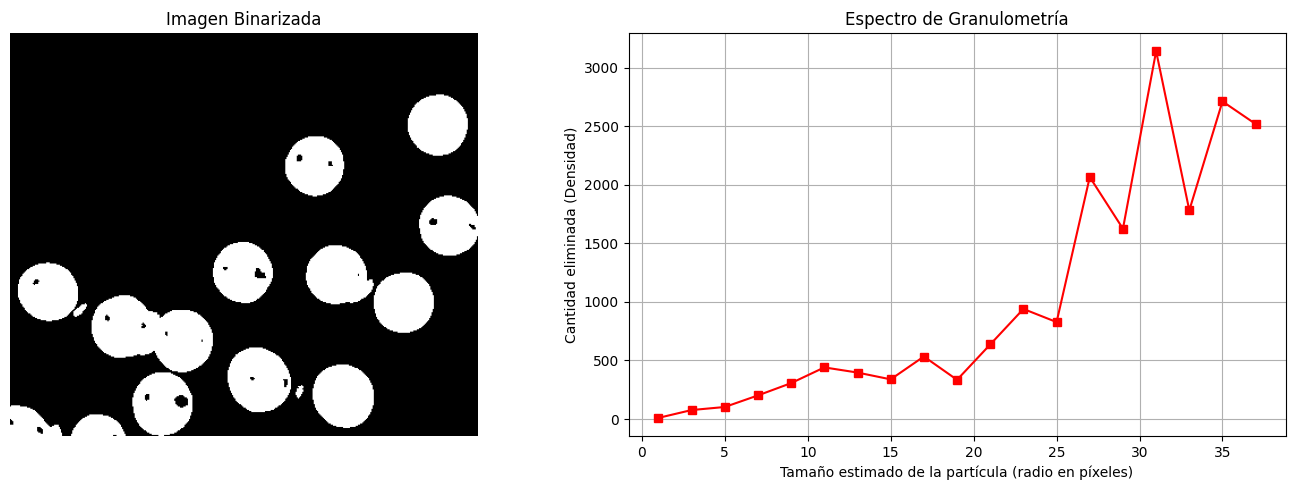

In [8]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

def realizar_granulometria(url_imagen):
    # Descargar la imagen desde la URL y convertirla a escala de grises
    try:
        req = urllib.request.urlopen(url_imagen)
        arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
        img_color = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        img_gris = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    except Exception as e:
        print(f"Error al cargar la imagen: {e}")
        return

    # Binarizar la imagen (Asumimos partículas sobre fondo oscuro o viceversa)
    # Usamos Otsu inverso para que las partículas queden blancas (255)
    _, binaria = cv2.threshold(img_gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    areas = []
    tamanos_radio = list(range(1, 40, 2)) # Radios del kernel de 1 a 39 saltando de a 2

    # Aplicar aperturas sucesivas
    for r in tamanos_radio:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (r, r))
        # La apertura elimina objetos menores al tamaño del kernel
        apertura = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel)
        
        # Sumamos los píxeles blancos restantes (área residual)
        area_actual = np.sum(apertura == 255)
        areas.append(area_actual)

    # Calcular el Espectro de Patrones (Derivada discreta)
    # La diferencia absoluta de áreas nos dice cuántas partículas se eliminaron en cada paso
    espectro = np.abs(np.diff(areas))
    radios_derivada = tamanos_radio[:-1]

    # Visualización e Interpretación
    plt.figure(figsize=(14, 5))

    # Mostrar la imagen binaria original
    plt.subplot(1, 2, 1)
    plt.imshow(binaria, cmap='gray')
    plt.title('Imagen Binarizada')
    plt.axis('off')

    # Mostrar la distribución de tamaños
    plt.subplot(1, 2, 2)
    plt.plot(radios_derivada, espectro, marker='s', color='red')
    plt.xlabel('Tamaño estimado de la partícula (radio en píxeles)')
    plt.ylabel('Cantidad eliminada (Densidad)')
    plt.title('Espectro de Granulometría')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


# Ejecutar con una imagen pública de ejemplo (como las grageas de OpenCV que funcionan bien como partículas)
url_particulas = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png'
realizar_granulometria(url_particulas)

Interpretación de los resultados:

- Los picos (puntos más altos) en la gráfica roja indican los tamaños predominantes de las partículas.

- Como ejemplo tenemos el del 30, así que la mayoría de las monedas tienen un tamaño de 30.

- Las zonas planas indican que casi no hay partículas de esos tamaños, como los más pequeños, entonces solo hay partículas grandes.